# DNN v3 — Sentence-Transformer Embeddings

Abordagem diferente do v2: em vez de TF-IDF, usa **embeddings pré-treinados** de um sentence-transformer.
Isto captura semântica e estilo de forma muito mais robusta e generalizável.

**Features:**
- `all-MiniLM-L6-v2`: 384-dim embeddings (rápido e eficaz)
- 18 features estilométricas (do v2)
- Total: 402 features

**Modelo:** FFNNv2 com BatchNorm, skip-connections, Optuna

In [2]:
import pickle

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.metrics import classification_report
from sentence_transformers import SentenceTransformer
import optuna

from text_features import extract_stylometric_features, apply_stylometric_features
from text_features import encode_labels, decode_labels
from ffnn import FFNNv2, evaluate_loss_accuracy

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', device)

N_CLASSES = 5

device: cuda
device: cuda


## *dados*

In [3]:
df_train = pd.read_csv('../datasets/dataset_v2_train.csv', sep=';')
df_test  = pd.read_csv('../datasets/dataset_v2_test.csv',  sep=';')
df_val   = pd.read_csv('../datasets/dataset_v2_val.csv',   sep=';')

# integrar dados revelados da Subm1
df_subm1 = pd.read_csv('../Subm1/subm1_labels_revealed.csv', sep=';')
LABEL_MAP = {'google': 'Google', 'anthropic': 'Anthropic', 'meta': 'Meta',
             'openai': 'Openai', 'human': 'Human'}
df_subm1['Label'] = df_subm1['Label'].str.lower().map(LABEL_MAP)

df_train_aug = pd.concat([df_train, df_subm1], ignore_index=True)

print(f'treino: {len(df_train_aug)} | teste: {len(df_test)} | val: {len(df_val)}')
print(df_train_aug['Label'].value_counts())

treino: 3600 | teste: 750 | val: 750
Label
Human        734
Meta         718
Anthropic    717
Google       717
Openai       714
Name: count, dtype: int64


## *gerar embeddings*

Usa `all-MiniLM-L6-v2` para gerar embeddings de 384 dimensões + 18 features estilométricas.

In [4]:
encoder = SentenceTransformer('all-MiniLM-L6-v2', device=device.type)
print(f'modelo carregado: all-MiniLM-L6-v2 ({encoder.get_sentence_embedding_dimension()} dims)')

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


modelo carregado: all-MiniLM-L6-v2 (384 dims)


In [5]:
train_texts = df_train_aug['Text'].fillna('').tolist()
test_texts  = df_test['Text'].fillna('').tolist()
val_texts   = df_val['Text'].fillna('').tolist()

print('a gerar embeddings...')
emb_train = encoder.encode(train_texts, show_progress_bar=True, batch_size=128)
emb_test  = encoder.encode(test_texts,  show_progress_bar=True, batch_size=128)
emb_val   = encoder.encode(val_texts,   show_progress_bar=True, batch_size=128)

print(f'embeddings shape: {emb_train.shape}')

a gerar embeddings...


Batches:   0%|          | 0/29 [00:00<?, ?it/s]

Batches:   0%|          | 0/6 [00:00<?, ?it/s]

Batches:   0%|          | 0/6 [00:00<?, ?it/s]

embeddings shape: (3600, 384)


In [6]:
# features estilométricas
style_train, style_means, style_stds = extract_stylometric_features(train_texts)
style_test  = apply_stylometric_features(test_texts,  style_means, style_stds)
style_val   = apply_stylometric_features(val_texts,   style_means, style_stds)

# combinar embeddings + estilometria
X_train = np.hstack([emb_train, style_train])
X_test  = np.hstack([emb_test,  style_test])
X_val   = np.hstack([emb_val,   style_val])

Y_train = encode_labels(df_train_aug['Label'].tolist())
Y_test  = encode_labels(df_test['Label'].tolist())
Y_val   = encode_labels(df_val['Label'].tolist())

print(f'features finais: {X_train.shape[1]} (embeddings: {emb_train.shape[1]} + estilometria: {style_train.shape[1]})')

features finais: 402 (embeddings: 384 + estilometria: 18)


In [7]:
def make_loader(X, y, batch_size=64, shuffle=False):
    Xt = torch.tensor(X, dtype=torch.float32)
    yt = torch.tensor(y, dtype=torch.long)
    return DataLoader(TensorDataset(Xt, yt), batch_size=batch_size, shuffle=shuffle)

train_loader = make_loader(X_train, Y_train, batch_size=64, shuffle=True)
test_loader  = make_loader(X_test,  Y_test,  batch_size=64)
val_loader   = make_loader(X_val,   Y_val,   batch_size=64)

print(f'X_train: {X_train.shape} | X_test: {X_test.shape} | X_val: {X_val.shape}')

X_train: (3600, 402) | X_test: (750, 402) | X_val: (750, 402)


## *optuna — otimização de hiperparâmetros*

In [8]:
def train_and_evaluate(model, train_loader, val_loader, criterion, optimizer, scheduler,
                       num_epochs=150, patience=20):
    best_val_acc = 0.0
    best_state = None
    no_improve = 0

    for epoch in range(1, num_epochs + 1):
        model.train()
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            loss = criterion(model(xb), yb)
            loss.backward()
            optimizer.step()

        val_loss, val_acc = evaluate_loss_accuracy(model, val_loader, criterion)
        scheduler.step(val_loss)

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
            no_improve = 0
        else:
            no_improve += 1
            if no_improve >= patience:
                break

    return best_val_acc, best_state

In [9]:
def objective(trial):
    n_layers   = trial.suggest_int('n_layers', 2, 4)
    topology   = [trial.suggest_categorical(f'dim_{i}', [64, 128, 256, 512]) for i in range(n_layers)]
    dropout    = trial.suggest_float('dropout', 0.1, 0.5)
    lr         = trial.suggest_float('lr', 1e-4, 5e-3, log=True)
    wd         = trial.suggest_float('weight_decay', 1e-5, 1e-2, log=True)
    smoothing  = trial.suggest_float('label_smoothing', 0.0, 0.15)
    activation = trial.suggest_categorical('activation', ['gelu', 'silu', 'relu'])

    model = FFNNv2(
        input_dim=X_train.shape[1], n_classes=N_CLASSES,
        topology=topology, dropout=dropout, activation=activation
    ).to(device)

    criterion = nn.CrossEntropyLoss(label_smoothing=smoothing)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=wd)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=7, factor=0.5)

    best_val_acc, _ = train_and_evaluate(model, train_loader, val_loader, criterion,
                                         optimizer, scheduler, num_epochs=150, patience=20)
    return best_val_acc


study = optuna.create_study(direction='maximize', study_name='dnn_v3_sbert')
study.optimize(objective, n_trials=50, show_progress_bar=True)

print(f'\nmelhor val_acc: {study.best_value:.4f}')
print('melhores hiperparâmetros:')
for k, v in study.best_params.items():
    print(f'  {k}: {v}')

[I 2026-03-30 04:42:21,726] A new study created in memory with name: dnn_v3_sbert


  0%|          | 0/50 [00:00<?, ?it/s]

[I 2026-03-30 04:42:33,179] Trial 0 finished with value: 0.996 and parameters: {'n_layers': 3, 'dim_0': 128, 'dim_1': 128, 'dim_2': 128, 'dropout': 0.3663028585142486, 'lr': 0.0016016886883403253, 'weight_decay': 0.00012196831405172158, 'label_smoothing': 0.03414400016711955, 'activation': 'relu'}. Best is trial 0 with value: 0.996.
[I 2026-03-30 04:42:46,860] Trial 1 finished with value: 0.9933333333333333 and parameters: {'n_layers': 3, 'dim_0': 512, 'dim_1': 512, 'dim_2': 256, 'dropout': 0.4497532241771438, 'lr': 0.0002213102920835388, 'weight_decay': 6.481562007182256e-05, 'label_smoothing': 0.10168958873216888, 'activation': 'silu'}. Best is trial 0 with value: 0.996.
[I 2026-03-30 04:42:58,906] Trial 2 finished with value: 0.9973333333333333 and parameters: {'n_layers': 2, 'dim_0': 256, 'dim_1': 256, 'dropout': 0.1474108408386993, 'lr': 0.0007024157637393881, 'weight_decay': 0.0016190299386920032, 'label_smoothing': 0.11535073495836108, 'activation': 'gelu'}. Best is trial 2 with

## *treino final*

In [10]:
bp = study.best_params
topology = [bp[f'dim_{i}'] for i in range(bp['n_layers'])]

print(f'Topologia: {topology}')
print(f'Dropout: {bp["dropout"]:.3f} | LR: {bp["lr"]:.5f} | WD: {bp["weight_decay"]:.5f}')
print(f'Label Smoothing: {bp["label_smoothing"]:.3f} | Activação: {bp["activation"]}')

Topologia: [64, 256]
Dropout: 0.324 | LR: 0.00310 | WD: 0.00143
Label Smoothing: 0.147 | Activação: gelu


In [11]:
model = FFNNv2(
    input_dim=X_train.shape[1], n_classes=N_CLASSES,
    topology=topology, dropout=bp['dropout'], activation=bp['activation']
).to(device)

criterion = nn.CrossEntropyLoss(label_smoothing=bp['label_smoothing'])
optimizer = torch.optim.AdamW(model.parameters(), lr=bp['lr'], weight_decay=bp['weight_decay'])
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=7, factor=0.5)

NUM_EPOCHS = 300
PATIENCE   = 30

best_val_acc = 0.0
best_state   = None
no_improve   = 0

train_losses, val_losses = [], []
train_accs,   val_accs   = [], []

for epoch in range(1, NUM_EPOCHS + 1):
    model.train()
    running_loss    = 0.0
    running_correct = 0
    running_total   = 0

    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        logits = model(xb)
        loss   = criterion(logits, yb)
        loss.backward()
        optimizer.step()

        running_loss    += loss.item() * xb.size(0)
        preds            = logits.argmax(dim=1)
        running_correct += (preds == yb).sum().item()
        running_total   += yb.size(0)

    train_loss = running_loss / running_total
    train_acc  = running_correct / running_total
    val_loss, val_acc = evaluate_loss_accuracy(model, val_loader, criterion)
    scheduler.step(val_loss)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)

    if epoch % 10 == 0:
        current_lr = optimizer.param_groups[0]['lr']
        print(f'Epoch {epoch:03d}/{NUM_EPOCHS} | train_loss={train_loss:.4f} | train_acc={train_acc:.4f} | val_loss={val_loss:.4f} | val_acc={val_acc:.4f} | lr={current_lr:.6f}')

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_state   = {k: v.clone() for k, v in model.state_dict().items()}
        no_improve   = 0
    else:
        no_improve += 1
        if no_improve >= PATIENCE:
            print(f'early stopping na epoch {epoch}')
            break

model.load_state_dict(best_state)
print(f'\nmelhor modelo -> val_acc={best_val_acc:.4f}')

Epoch 010/300 | train_loss=0.6011 | train_acc=0.9861 | val_loss=0.5574 | val_acc=0.9920 | lr=0.003101
Epoch 020/300 | train_loss=0.5735 | train_acc=0.9939 | val_loss=0.5474 | val_acc=0.9920 | lr=0.003101
Epoch 030/300 | train_loss=0.5639 | train_acc=0.9975 | val_loss=0.5479 | val_acc=0.9933 | lr=0.003101
early stopping na epoch 35

melhor modelo -> val_acc=0.9947


## *curvas de treino*

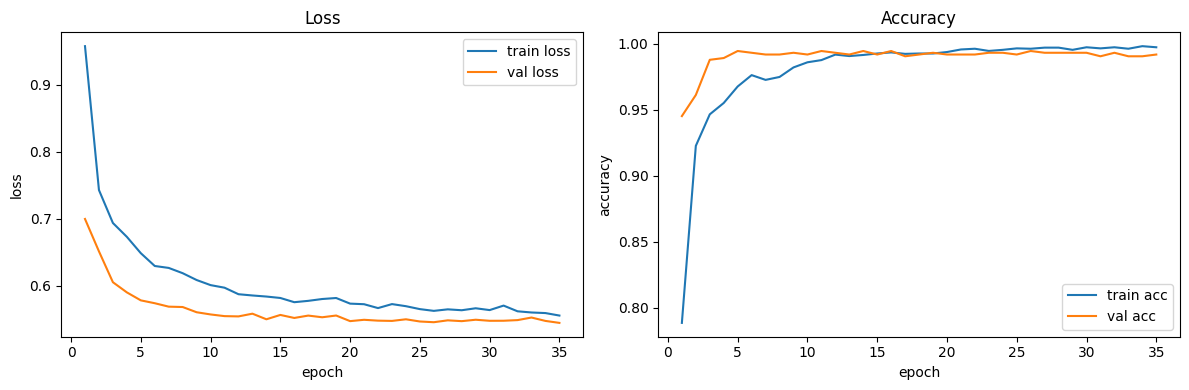

[TRAIN] accuracy=0.9928
[TEST]  accuracy=0.9920
[VAL]   accuracy=0.9947


In [12]:
epochs_range = range(1, len(train_losses) + 1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(epochs_range, train_losses, label='train loss')
axes[0].plot(epochs_range, val_losses,   label='val loss')
axes[0].set_xlabel('epoch')
axes[0].set_ylabel('loss')
axes[0].set_title('Loss')
axes[0].legend()

axes[1].plot(epochs_range, train_accs, label='train acc')
axes[1].plot(epochs_range, val_accs,   label='val acc')
axes[1].set_xlabel('epoch')
axes[1].set_ylabel('accuracy')
axes[1].set_title('Accuracy')
axes[1].legend()

plt.tight_layout()
plt.show()

_, train_acc = evaluate_loss_accuracy(model, train_loader, criterion)
_, test_acc  = evaluate_loss_accuracy(model, test_loader,  criterion)
_, val_acc   = evaluate_loss_accuracy(model, val_loader,   criterion)
print(f'[TRAIN] accuracy={train_acc:.4f}')
print(f'[TEST]  accuracy={test_acc:.4f}')
print(f'[VAL]   accuracy={val_acc:.4f}')

## *guardar modelo*

In [13]:
torch.save(model.state_dict(), '../models/model_dnn_v3.pt')

# guardar stats da estilometria para inferência
with open('../models/dnn_v3_style_stats.pkl', 'wb') as f:
    pickle.dump({'means': style_means, 'stds': style_stds}, f)

with open('../models/dnn_v3_best_params.pkl', 'wb') as f:
    pickle.dump(study.best_params, f)

print('modelo e parâmetros guardados.')
print(f'  para inferência usar: all-MiniLM-L6-v2 + style_stats + model_dnn_v3.pt')

modelo e parâmetros guardados.
  para inferência usar: all-MiniLM-L6-v2 + style_stats + model_dnn_v3.pt


## *avaliação com dataset-exemplos*

In [14]:
df_ex = pd.read_csv('../datasets/dataset-exemplos.csv', sep=';')
ex_texts = df_ex['Text'].fillna('').tolist()

emb_ex   = encoder.encode(ex_texts, show_progress_bar=True, batch_size=128)
style_ex = apply_stylometric_features(ex_texts, style_means, style_stds)
X_ex     = np.hstack([emb_ex, style_ex])
Y_ex     = encode_labels(df_ex['Label'].tolist())
ex_loader = make_loader(X_ex, Y_ex, batch_size=64)

model.eval()
preds_all = []
with torch.no_grad():
    for xb, _ in ex_loader:
        logits = model(xb.to(device))
        preds_all.extend(logits.argmax(dim=1).cpu().tolist())

preds_decoded = decode_labels(preds_all)
print(classification_report(
    df_ex['Label'].str.lower().tolist(),
    preds_decoded,
    digits=3
))

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

              precision    recall  f1-score   support

   anthropic      0.500     0.348     0.410        23
      google      0.455     0.312     0.370        16
       human      0.548     0.981     0.703        52
        meta      0.667     0.118     0.200        17
      openai      0.500     0.059     0.105        17

    accuracy                          0.536       125
   macro avg      0.534     0.364     0.358       125
weighted avg      0.537     0.536     0.457       125



## *avaliação com Subm1*

In [15]:
subm1_texts = df_subm1['Text'].fillna('').tolist()
emb_s1      = encoder.encode(subm1_texts, show_progress_bar=True, batch_size=128)
style_s1    = apply_stylometric_features(subm1_texts, style_means, style_stds)
X_subm1     = np.hstack([emb_s1, style_s1])
Y_subm1     = encode_labels(df_subm1['Label'].tolist())
subm1_loader = make_loader(X_subm1, Y_subm1, batch_size=64)

model.eval()
preds_all = []
with torch.no_grad():
    for xb, _ in subm1_loader:
        logits = model(xb.to(device))
        preds_all.extend(logits.argmax(dim=1).cpu().tolist())

preds_decoded = decode_labels(preds_all)
print(classification_report(
    df_subm1['Label'].str.lower().tolist(),
    preds_decoded,
    digits=3
))

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

              precision    recall  f1-score   support

   anthropic      0.688     0.647     0.667        17
      google      0.769     0.588     0.667        17
       human      0.786     0.971     0.868        34
        meta      0.895     0.944     0.919        18
      openai      0.600     0.429     0.500        14

    accuracy                          0.770       100
   macro avg      0.747     0.716     0.724       100
weighted avg      0.760     0.770     0.757       100

